In [19]:

datos1 = {
    'estudiante': ['Ana', 'Luis', 'María', 'Carlos', 'Rosa',
                   'Pedro', 'Julia', 'Marco', 'Sara', 'Diego'],
    'nota_parcial': [14, 12, 18, 15, 11, 17, 13, 16, 15, 14],
    'nota_final':   [15, 13, 19, 14, 12, 18, 14, 17, 16, 13],
    'asistencia':   [90, 75, 98, 85, 70, 95, 80, 92, 88, 78]
}
df = pd.DataFrame(datos1)

print("=== MI PRIMER DATAFRAME ===")
print(df)
print("\n=== ESTADÍSTICAS ===")
print(df.describe())

=== MI PRIMER DATAFRAME ===
  estudiante  nota_parcial  nota_final  asistencia
0        Ana            14          15          90
1       Luis            12          13          75
2      María            18          19          98
3     Carlos            15          14          85
4       Rosa            11          12          70
5      Pedro            17          18          95
6      Julia            13          14          80
7      Marco            16          17          92
8       Sara            15          16          88
9      Diego            14          13          78

=== ESTADÍSTICAS ===
       nota_parcial  nota_final  asistencia
count     10.000000   10.000000   10.000000
mean      14.500000   15.100000   85.100000
std        2.173067    2.330951    9.134185
min       11.000000   12.000000   70.000000
25%       13.250000   13.250000   78.500000
50%       14.500000   14.500000   86.500000
75%       15.750000   16.750000   91.500000
max       18.000000   19.000000   98.

In [20]:

aprobados = df[df['nota_final'] >= 15]
print("Aprobados con nota >= 15:")
print(aprobados)

Aprobados con nota >= 15:
  estudiante  nota_parcial  nota_final  asistencia
0        Ana            14          15          90
2      María            18          19          98
5      Pedro            17          18          95
7      Marco            16          17          92
8       Sara            15          16          88


In [21]:

mejor = df[df['nota_final'] == df['nota_final'].max()]
print("Mejor estudiante:")
print(mejor)

Mejor estudiante:
  estudiante  nota_parcial  nota_final  asistencia
2      María            18          19          98


In [22]:

print("Promedio nota parcial:", df['nota_parcial'].mean())
print("Promedio nota final:", df['nota_final'].mean())
print("¿Mejoraron entre parcial y final?", 
      df['nota_final'].mean() > df['nota_parcial'].mean())

Promedio nota parcial: 14.5
Promedio nota final: 15.1
¿Mejoraron entre parcial y final? True


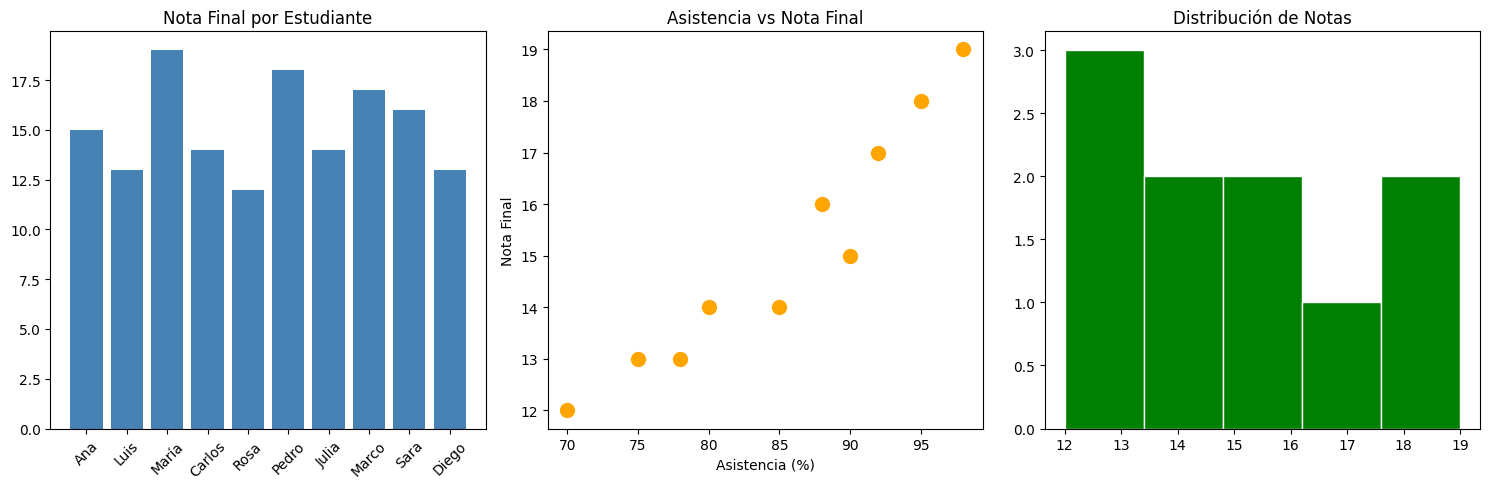

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Comparar notas
axes[0].bar(df['estudiante'], df['nota_final'], color='steelblue')
axes[0].set_title('Nota Final por Estudiante')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Relación asistencia vs nota
axes[1].scatter(df['asistencia'], df['nota_final'], color='orange', s=100)
axes[1].set_xlabel('Asistencia (%)')
axes[1].set_ylabel('Nota Final')
axes[1].set_title('Asistencia vs Nota Final')

# Gráfico 3: Distribución de notas
axes[2].hist(df['nota_final'], bins=5, color='green', edgecolor='white')
axes[2].set_title('Distribución de Notas')

plt.tight_layout()
plt.show()

In [24]:
correlacion = df['asistencia'].corr(df['nota_final'])
print(f"Correlación asistencia-nota: {correlacion:.2f}")

Correlación asistencia-nota: 0.95


In [25]:

outliers = df[(df['asistencia'] <= 90) & (df['nota_final'] >= 15)]
print("Estudiantes con buena nota pero poca asistencia:")
print(outliers)

Estudiantes con buena nota pero poca asistencia:
  estudiante  nota_parcial  nota_final  asistencia
0        Ana            14          15          90
8       Sara            15          16          88


In [26]:
df['mejoro'] = df['nota_final'] > df['nota_parcial']
print("¿Quién mejoró entre parcial y final?")
print(df[['estudiante', 'nota_parcial', 'nota_final', 'mejoro']])

¿Quién mejoró entre parcial y final?
  estudiante  nota_parcial  nota_final  mejoro
0        Ana            14          15    True
1       Luis            12          13    True
2      María            18          19    True
3     Carlos            15          14   False
4       Rosa            11          12    True
5      Pedro            17          18    True
6      Julia            13          14    True
7      Marco            16          17    True
8       Sara            15          16    True
9      Diego            14          13   False


In [27]:
print("="*45)
print("   REPORTE DE ANÁLISIS ESTUDIANTIL")
print("="*45)
print(f"\nTotal estudiantes analizados: {len(df)}")
print(f"Promedio nota final:     {df['nota_final'].mean():.1f}")
print(f"Promedio asistencia:     {df['asistencia'].mean():.1f}%")
print(f"Correlación asistencia-nota: {df['asistencia'].corr(df['nota_final']):.2f}")
print(f"\nEstudiantes que mejoraron: {df['mejoro'].sum()} de {len(df)}")
print(f"Mejor estudiante: {df.loc[df['nota_final'].idxmax(), 'estudiante']} "
      f"con {df['nota_final'].max()}")
print(f"Menor nota: {df.loc[df['nota_final'].idxmin(), 'estudiante']} "
      f"con {df['nota_final'].min()}")
print("\nCONCLUSIÓN:")
print("A mayor asistencia, mejor nota final (correlación 0.95)")
print("El 80% de estudiantes mejoró entre parcial y final")

   REPORTE DE ANÁLISIS ESTUDIANTIL

Total estudiantes analizados: 10
Promedio nota final:     15.1
Promedio asistencia:     85.1%
Correlación asistencia-nota: 0.95

Estudiantes que mejoraron: 8 de 10
Mejor estudiante: María con 19
Menor nota: Rosa con 12

CONCLUSIÓN:
A mayor asistencia, mejor nota final (correlación 0.95)
El 80% de estudiantes mejoró entre parcial y final


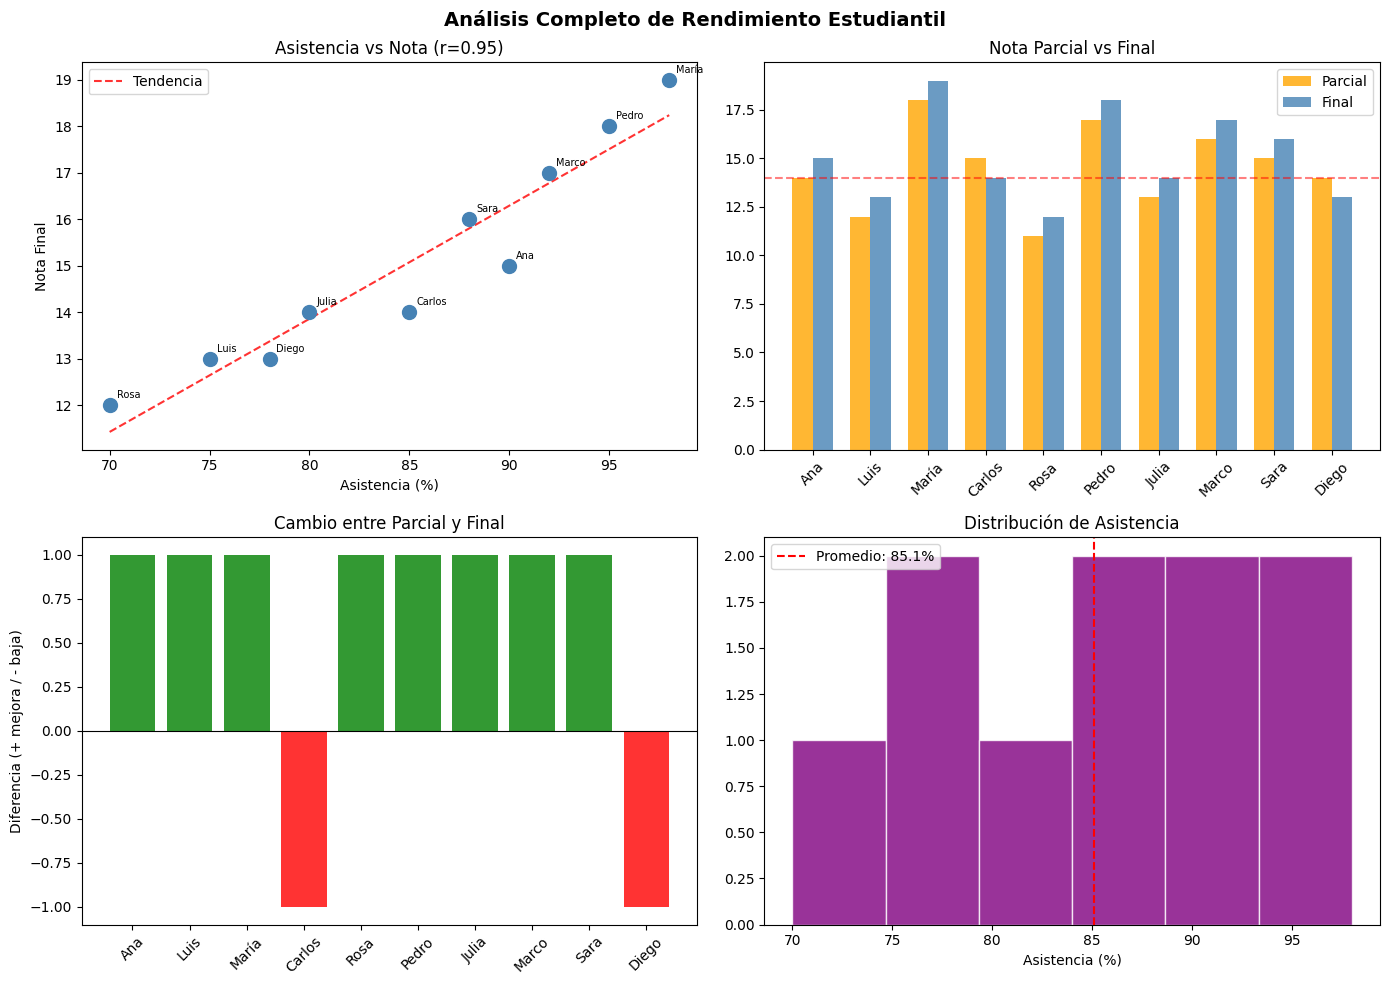

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Completo de Rendimiento Estudiantil', 
             fontsize=14, fontweight='bold')

# Gráfico 1: Scatter con línea de tendencia
import numpy as np
axes[0,0].scatter(df['asistencia'], df['nota_final'], 
                  color='steelblue', s=100, zorder=5)
z = np.polyfit(df['asistencia'], df['nota_final'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['asistencia'].min(), df['asistencia'].max(), 100)
axes[0,0].plot(x_line, p(x_line), "r--", alpha=0.8, label='Tendencia')
axes[0,0].set_xlabel('Asistencia (%)')
axes[0,0].set_ylabel('Nota Final')
axes[0,0].set_title(f'Asistencia vs Nota (r={df["asistencia"].corr(df["nota_final"]):.2f})')
axes[0,0].legend()

for _, row in df.iterrows():
    axes[0,0].annotate(row['estudiante'], 
                       (row['asistencia'], row['nota_final']),
                       textcoords="offset points", xytext=(5,5), fontsize=7)

# Gráfico 2: Parcial vs Final por estudiante
x = np.arange(len(df))
width = 0.35
axes[0,1].bar(x - width/2, df['nota_parcial'], width, 
              label='Parcial', color='orange', alpha=0.8)
axes[0,1].bar(x + width/2, df['nota_final'], width, 
              label='Final', color='steelblue', alpha=0.8)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df['estudiante'], rotation=45)
axes[0,1].set_title('Nota Parcial vs Final')
axes[0,1].legend()
axes[0,1].axhline(y=14, color='red', linestyle='--', 
                   alpha=0.5, label='Mínimo aprobatorio')

# Gráfico 3: Quién mejoró?
colores = ['green' if m else 'red' for m in df['mejoro']]
diferencia = df['nota_final'] - df['nota_parcial']
axes[1,0].bar(df['estudiante'], diferencia, color=colores, alpha=0.8)
axes[1,0].axhline(y=0, color='black', linewidth=0.8)
axes[1,0].set_title('Cambio entre Parcial y Final')
axes[1,0].set_ylabel('Diferencia (+ mejora / - baja)')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Distribución de asistencia
axes[1,1].hist(df['asistencia'], bins=6, 
               color='purple', edgecolor='white', alpha=0.8)
axes[1,1].axvline(x=df['asistencia'].mean(), color='red', 
                   linestyle='--', label=f'Promedio: {df["asistencia"].mean():.1f}%')
axes[1,1].set_title('Distribución de Asistencia')
axes[1,1].set_xlabel('Asistencia (%)')
axes[1,1].legend()

plt.tight_layout()
plt.show()